# Collapse thresholds (classifier AUC)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root, so `import src...` works

import numpy as np
import pandas as pd
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.cm as cm

from scipy import signal, stats
from scipy.optimize import curve_fit

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from IPython.display import display, Image

from src import config as cfg
from src import ecog_cnn as ec
from src.io_utils import save_fig, save_cache, load_cache, get_device

rcParams['figure.figsize'] = [14, 4]
rcParams['font.size'] = 12
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

np.random.seed(cfg.RNG_SEED)


In [2]:
usable = cfg.usable
NOISE_LEVELS = cfg.NOISE_LEVELS
CONDITIONS = cfg.CONDITIONS
N_COND = cfg.N_COND
GROUP_NAMES = cfg.GROUP_NAMES
layer_names = cfg.layer_names
n_stim = cfg.n_stim
fs = cfg.fs
trange_d1 = cfg.trange_d1
baseline_d1 = cfg.baseline_d1
response_d1 = cfg.response_d1
trange_d2 = cfg.trange_d2
response_win = cfg.response_win
AUC_CRIT = cfg.AUC_CRIT
FACE_SEL_THRESH = cfg.FACE_SEL_THRESH
FACE_SEL_CRIT = cfg.FACE_SEL_CRIT
WIN_WIDTH, WIN_STEP, WIN_STARTS = cfg.WIN_WIDTH, cfg.WIN_STEP, cfg.WIN_STARTS
MIN_TRIALS_PER_CONDITION = cfg.MIN_TRIALS_PER_CONDITION
MIN_GROUP_SIZE = cfg.MIN_GROUP_SIZE
NOISE_HALFWIN = cfg.NOISE_HALFWIN
POP_HALFWIN = cfg.POP_HALFWIN
MIN_TRIALS_POP = cfg.MIN_TRIALS_POP

common_average_reference = ec.common_average_reference
broadband_power = ec.broadband_power
classify_region = ec.classify_region
compute_avg_magnitude = ec.compute_avg_magnitude
phase_scramble = ec.phase_scramble
crossnobis_1d = ec.crossnobis_1d
crossnobis_multivariate = ec.crossnobis_multivariate
cv_auc = ec.cv_auc
mean_ci95 = ec.mean_ci95
upper_tri = ec.upper_tri
compare_rdms = ec.compare_rdms
filter_outlier_trials = ec.filter_outlier_trials
partial_spearman = ec.partial_spearman
threshold_cross = ec.threshold_cross
corr_sigmoid = ec.corr_sigmoid
auc_sigmoid = ec.auc_sigmoid
fit_threshold = ec.fit_threshold
build_layer_rdm_crossnobis = ec.build_layer_rdm_crossnobis
build_layer_rdms_bootstrap_once = ec.build_layer_rdms_bootstrap_once
similarity_to_baseline = ec.similarity_to_baseline
build_comparison_df = ec.build_comparison_df
auc_face_vs_house = ec.auc_face_vs_house
perm = ec.category_major_perm()
reorder_rdm = ec.reorder_rdm
get_noise_window_indices = ec.get_noise_window_indices
subset_rdm = ec.subset_rdm

REG_COLORS = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange'}
group_colors = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange',
                'face_selective': 'tab:red', 'all': 'tab:gray'}
COND_NOISE = np.array([int(c.split('_')[1]) for c in CONDITIONS])
COND_ISFACE = np.array([c.startswith('face') for c in CONDITIONS]).astype(int)
layer_x = np.arange(len(layer_names))


In [3]:
_c = load_cache('02_electrode_characterization')
electrode_type_df = _c['electrode_type_df']

_c = load_cache('05_cnn_representations')
raw_cnn_acts = _c['raw_cnn_acts']

_c = load_cache('07_per_electrode_correspondence')
elec_cache = _c['elec_cache']
elec = _c['elec']
face_sel_dat1 = _c['face_sel_dat1']


## Collapse threshold definition

RDM-collapse (when a layer's RDM stops resembling its own clean RDM) measures
*when the representation changes*, not *when the face/house decision fails*,
and is biased low regardless of how well a system actually discriminates.
The noise threshold (theta) used from here on is instead the noise level
where a cross-validated face-vs-house classifier's AUC first drops below a
fixed, pre-specified criterion (0.75) -- the same decision-based ruler for
the CNN and for the brain.


In [4]:
# @title Collapse thresholds via classifier AUC, per electrode: theta_CNN vs. theta_neural

AUC_CRIT = 0.75   # fixed BEFORE looking at the neural result, from the CNN clean-curve knee

# --- theta_CNN: per layer, classifier trained/tested at each noise level ---
cnn_rows = []
for L in layer_names:
    d = raw_cnn_acts[L]
    curve = np.full(len(NOISE_LEVELS), np.nan)
    for k, n in enumerate(NOISE_LEVELS):
        Xf, Xh = np.asarray(d[f'face_{n}']), np.asarray(d[f'house_{n}'])
        X = np.vstack([Xf, Xh]); y = np.r_[np.ones(len(Xf)), np.zeros(len(Xh))]
        curve[k] = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
                                    X, y, cv=5, scoring='roc_auc').mean()
    cnn_rows.append(dict(layer=L, theta=threshold_cross(NOISE_LEVELS, curve), curve=curve))
cnn_thr = pd.DataFrame(cnn_rows)
print(f'theta_CNN by AUC (criterion {AUC_CRIT}):')
print(cnn_thr[['layer', 'theta']].to_string(index=False))
deep_cnn = cnn_thr[cnn_thr['layer'].isin(['pool5', 'fc6', 'fc7'])]['theta'].mean()
print(f'deep-layer mean theta_CNN = {deep_cnn:.1f}%')

# --- theta_neural: per ventral-temporal electrode ---
def neural_curve(s, ch):
    c = elec_cache[s]
    if ch not in c['good']:
        return None
    x = c['resp'][:, np.where(c['good'] == ch)[0][0]]
    y = (c['cat'] == 2).astype(int)
    curve = np.full(len(NOISE_LEVELS), np.nan)
    for k, n in enumerate(NOISE_LEVELS):
        m = np.abs(c['noise'] - n) <= 10
        if m.sum() >= 12:
            curve[k] = cv_auc(x[m], y[m])
    return curve

vt = elec[elec['region'] == 'ventral_temporal'].copy()
th, curves = [], {}
for _, r in vt.iterrows():
    s, ch = int(r['subject']), int(r['channel'])
    cv = neural_curve(s, ch); curves[(s, ch)] = cv
    th.append(threshold_cross(NOISE_LEVELS, cv) if cv is not None else np.nan)
vt['theta_neural'] = th
n_valid = vt['theta_neural'].notna().sum()
print(f'\ntheta_neural by AUC (criterion {AUC_CRIT}), ventral temporal: {n_valid}/{len(vt)} electrodes reach AUC {AUC_CRIT} clean')
for s in usable:
    t = vt.loc[vt['subject'] == s, 'theta_neural'].dropna()
    if len(t):
        print(f'  S{s}: median={t.median():.1f}% (n={len(t)})')
neural_med = vt['theta_neural'].median()
print(f'  AGGREGATED median theta_neural = {neural_med:.1f}%')

# --- bootstrap 95% CI on both medians (resampling electrodes / layers) ---
rng = np.random.RandomState(0)
neural_vals = vt['theta_neural'].dropna().values
cnn_vals = cnn_thr.loc[cnn_thr['layer'].isin(['pool5','fc6','fc7']), 'theta'].dropna().values
boot_neural = [np.median(rng.choice(neural_vals, size=len(neural_vals), replace=True)) for _ in range(2000)] if len(neural_vals) >= 2 else []
boot_cnn = [np.median(rng.choice(cnn_vals, size=len(cnn_vals), replace=True)) for _ in range(2000)] if len(cnn_vals) >= 2 else []

print(f'\n>>> RESULT (criterion {AUC_CRIT}):')
print(f'    theta_CNN (deep)  = {deep_cnn:.1f}%' + (f'  [95% CI {np.percentile(boot_cnn,2.5):.1f}-{np.percentile(boot_cnn,97.5):.1f}%]' if boot_cnn else '  [CI unavailable, n too small]'))
print(f'    theta_neural      = {neural_med:.1f}%' + (f'  [95% CI {np.percentile(boot_neural,2.5):.1f}-{np.percentile(boot_neural,97.5):.1f}%]' if boot_neural else '  [CI unavailable, n too small]'))
print(f'    difference        = {abs(deep_cnn - neural_med):.1f} pp')
print(f'    Miller landmark   = ~50% (from HIS stimuli -- comparable only if noise scales match, unverifiable without behaviour)')


theta_CNN by AUC (criterion 0.75):
layer     theta
pool1 61.288107
pool2 62.303527
pool3 63.979882
pool4 63.304682
pool5 57.104279
  fc6 57.371001
  fc7 50.736660
deep-layer mean theta_CNN = 55.1%



theta_neural by AUC (criterion 0.75), ventral temporal: 4/77 electrodes reach AUC 0.75 clean
  S0: median=36.8% (n=1)
  S3: median=39.4% (n=1)
  S4: median=31.9% (n=1)
  S6: median=8.2% (n=1)
  AGGREGATED median theta_neural = 34.4%

>>> RESULT (criterion 0.75):
    theta_CNN (deep)  = 55.1%  [95% CI 50.7-57.4%]
    theta_neural      = 34.4%  [95% CI 8.2-39.4%]
    difference        = 20.7 pp
    Miller landmark   = ~50% (from HIS stimuli -- comparable only if noise scales match, unverifiable without behaviour)


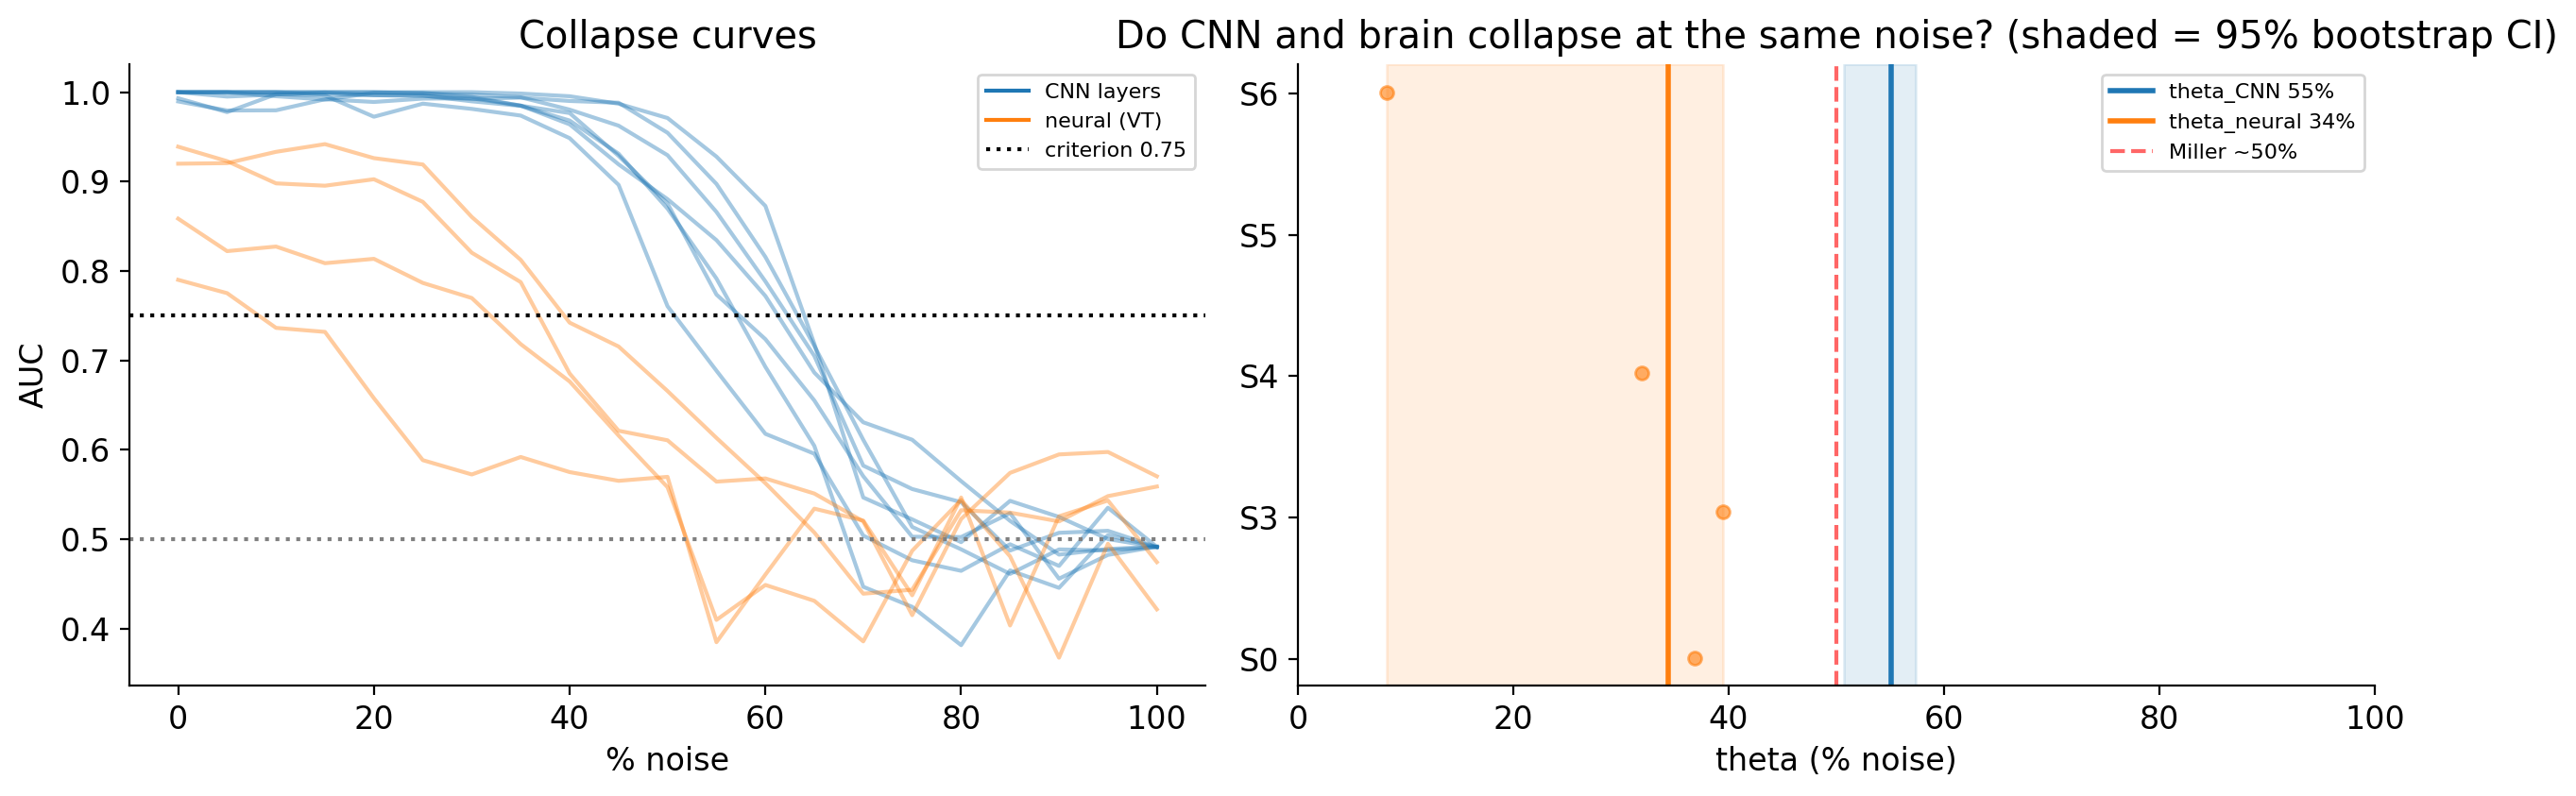

In [5]:
# @title Collapse curves and thresholds with bootstrap CI

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for _, r in cnn_thr.iterrows():
    ax[0].plot(NOISE_LEVELS, r['curve'], '-', alpha=.4, color='tab:blue')
ax[0].plot([], [], '-', color='tab:blue', label='CNN layers')
best_neural = vt.dropna(subset=['theta_neural']).nlargest(8, 'theta_neural')
for _, r in best_neural.iterrows():
    cv = curves[(int(r['subject']), int(r['channel']))]
    ax[0].plot(NOISE_LEVELS, cv, '-', alpha=.4, color='tab:orange')
ax[0].plot([], [], '-', color='tab:orange', label='neural (VT)')
ax[0].axhline(AUC_CRIT, color='k', ls=':', label=f'criterion {AUC_CRIT}'); ax[0].axhline(.5, color='gray', ls=':')
ax[0].set_xlabel('% noise'); ax[0].set_ylabel('AUC'); ax[0].legend(fontsize=8); ax[0].set_title('Collapse curves')

ax[1].axvline(deep_cnn, color='tab:blue', lw=2, label=f'theta_CNN {deep_cnn:.0f}%')
if boot_cnn:
    ax[1].axvspan(np.percentile(boot_cnn,2.5), np.percentile(boot_cnn,97.5), color='tab:blue', alpha=0.12)
ax[1].axvline(neural_med, color='tab:orange', lw=2, label=f'theta_neural {neural_med:.0f}%')
if boot_neural:
    ax[1].axvspan(np.percentile(boot_neural,2.5), np.percentile(boot_neural,97.5), color='tab:orange', alpha=0.12)
ax[1].axvline(50, color='r', ls='--', alpha=.6, label='Miller ~50%')
for i, s in enumerate(usable):
    t = vt.loc[vt['subject'] == s, 'theta_neural'].dropna()
    if len(t):
        ax[1].scatter(t, np.full(len(t), i)+np.random.uniform(-.1,.1,len(t)), color='tab:orange', alpha=.6, s=25)
ax[1].set_yticks(range(len(usable))); ax[1].set_yticklabels([f'S{s}' for s in usable])
ax[1].set_xlabel('theta (% noise)'); ax[1].set_xlim(0, 100); ax[1].legend(fontsize=8)
ax[1].set_title('Do CNN and brain collapse at the same noise? (shaded = 95% bootstrap CI)')
plt.tight_layout(); display(Image(save_fig(fig, '08_collapse_thresholds_fig01'))); plt.close(fig)



CRITERION SENSITIVITY (ventral temporal)
 crit | n valid | theta_neural med | theta_CNN deep
--------------------------------------------------
 0.60 |      17 |            24.2% |          65.8%
 0.65 |      10 |            34.3% |          61.8%
 0.70 |       5 |            37.2% |          58.5%
 0.75 |       4 |            34.4% |          55.1%

PER SUBJECT (criterion 0.75):
theta_CNN (deep, shared reference) = 55.1%

  S0: theta_neural=36.8% (n=1), vs theta_CNN: -18.2pp
  S3: theta_neural=39.4% (n=1), vs theta_CNN: -15.6pp
  S4: theta_neural=31.9% (n=1), vs theta_CNN: -23.2pp
  S5: no VT electrode reaches 0.75 clean -- theta_neural not measurable
  S6: theta_neural=8.2% (n=1), vs theta_CNN: -46.8pp


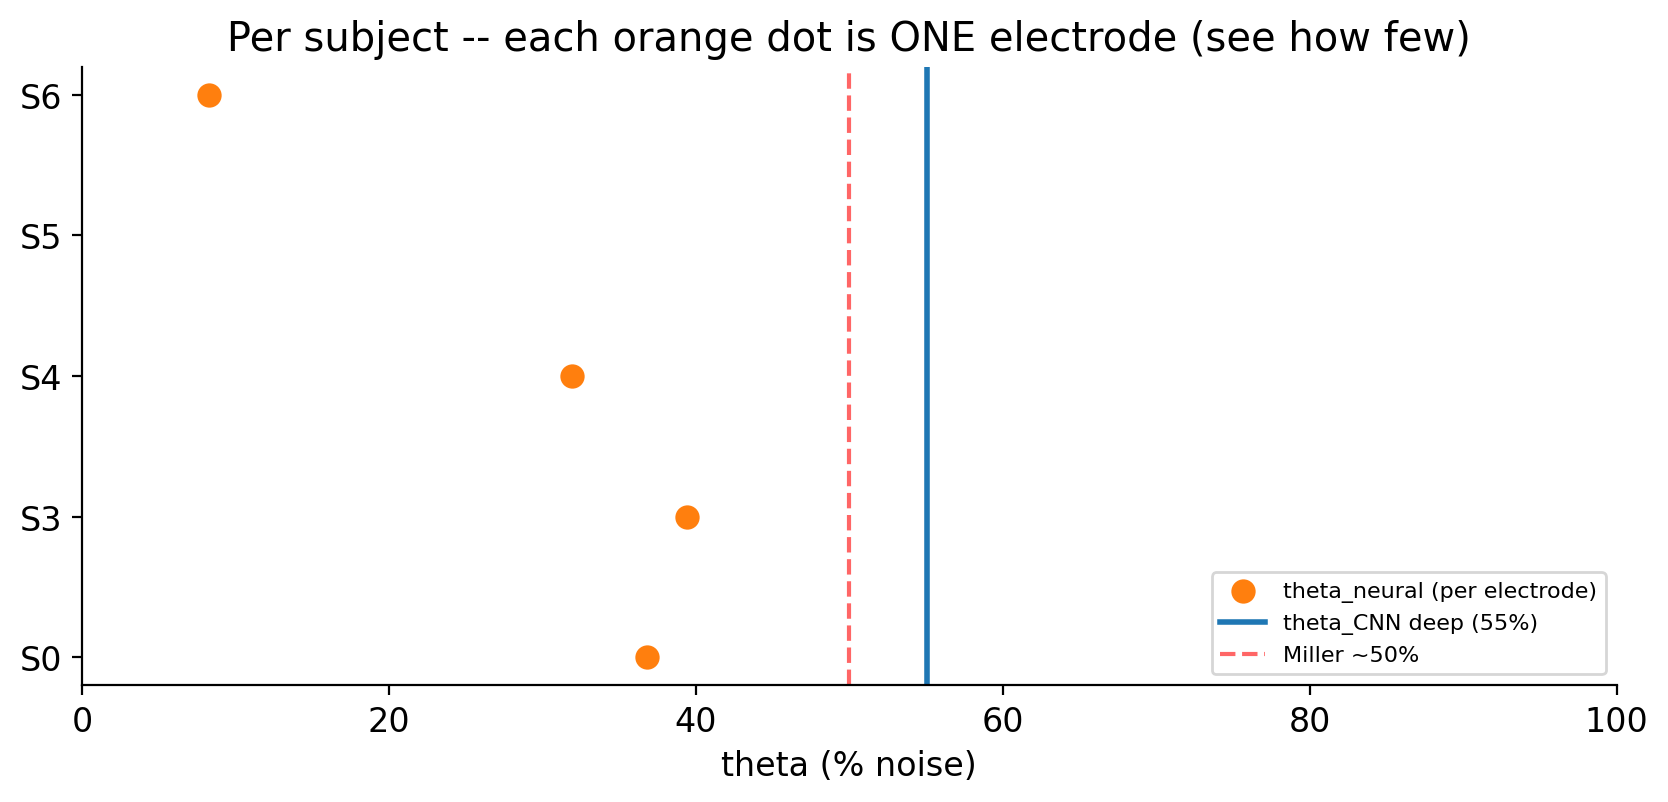

In [6]:
# @title Per-subject view + criterion sensitivity (how much does the 0.75 choice matter?)

print('CRITERION SENSITIVITY (ventral temporal)')
print(f'{"crit":>5} | {"n valid":>7} | {"theta_neural med":>16} | {"theta_CNN deep":>14}')
print('-'*50)
vt_curves = {(int(r.subject), int(r.channel)): curves[(int(r.subject), int(r.channel))]
             for r in vt.itertuples() if (int(r.subject), int(r.channel)) in curves}
for crit in [0.60, 0.65, 0.70, 0.75]:
    th_n = [threshold_cross(NOISE_LEVELS, cv, crit) for cv in vt_curves.values()]
    th_n = [t for t in th_n if np.isfinite(t)]
    th_c = [threshold_cross(NOISE_LEVELS, r['curve'], crit) for _, r in cnn_thr.iterrows() if r['layer'] in ['pool5','fc6','fc7']]
    th_c = [t for t in th_c if np.isfinite(t)]
    print(f'{crit:>5.2f} | {len(th_n):>7d} | '
          f'{(f"{np.median(th_n):.1f}%" if th_n else "-"):>16} | '
          f'{(f"{np.mean(th_c):.1f}%" if th_c else "-"):>14}')

print('\nPER SUBJECT (criterion 0.75):')
print(f'theta_CNN (deep, shared reference) = {deep_cnn:.1f}%\n')
for s in usable:
    t = vt.loc[vt['subject'] == s, 'theta_neural'].dropna()
    if len(t) == 0:
        print(f'  S{s}: no VT electrode reaches 0.75 clean -- theta_neural not measurable')
    else:
        print(f'  S{s}: theta_neural={t.median():.1f}% (n={len(t)}), vs theta_CNN: {t.median()-deep_cnn:+.1f}pp')

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for i, s in enumerate(usable):
    t = vt.loc[vt['subject'] == s, 'theta_neural'].dropna()
    if len(t):
        ax.scatter(t, np.full(len(t), i), color='tab:orange', s=60, zorder=3,
                   label='theta_neural (per electrode)' if i == 0 else None)
ax.axvline(deep_cnn, color='tab:blue', lw=2, label=f'theta_CNN deep ({deep_cnn:.0f}%)')
ax.axvline(50, color='r', ls='--', alpha=.6, label='Miller ~50%')
ax.set_yticks(range(len(usable))); ax.set_yticklabels([f'S{s}' for s in usable])
ax.set_xlabel('theta (% noise)'); ax.set_xlim(0, 100); ax.legend(fontsize=8, loc='lower right')
ax.set_title('Per subject -- each orange dot is ONE electrode (see how few)')
plt.tight_layout(); display(Image(save_fig(fig, '08_collapse_thresholds_fig02'))); plt.close(fig)



## Collapse thresholds across all three electrode groups

The result above used only `ventral_temporal`. Two natural questions
follow: does `early_visual` collapse at a different noise level (a
within-brain hierarchy check), and what does theta look like for the
electrodes that are most confidently face-selective (using the independent
`face_sel_dat1` marker from the section above, not the dat2-derived
`face_selective` used elsewhere in this notebook -- reusing that would be
circular, since it's built from the same AUC-vs-noise curve theta is fit to)?

`face_selective` here is a **functional ceiling**, expected to overlap
heavily with `ventral_temporal` anatomically -- it is not a third
independent brain region.


In [7]:
# @title Collapse thresholds, three groups (early_visual, ventral_temporal, face_selective-via-dat1)

GROUPS3 = ['early_visual', 'ventral_temporal', 'face_selective']
GCOL3 = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange', 'face_selective': 'tab:red'}

rows3, curve_store3 = [], {}
for _, r in elec.iterrows():
    s, ch, reg = int(r['subject']), int(r['channel']), r['region']
    cv = neural_curve(s, ch); curve_store3[(s, ch)] = cv
    th = threshold_cross(NOISE_LEVELS, cv) if cv is not None else np.nan
    groups_ = []
    if reg in ('early_visual', 'ventral_temporal'):
        groups_.append(reg)
    if face_sel_dat1.get((s, ch), False):
        groups_.append('face_selective')
    for g in groups_:
        rows3.append(dict(subject=s, channel=ch, group=g, theta_neural=th))
neu3 = pd.DataFrame(rows3)

print(f"theta_neural by AUC (criterion {AUC_CRIT}), three groups "
      f"(face_selective = dat1-localizer AUC>{FACE_SEL_CRIT}, independent of the curve being tested):")
for g in GROUPS3:
    sub = neu3[neu3['group'] == g]
    nvalid = sub['theta_neural'].notna().sum()
    tag = ' (functional ceiling, overlaps ventral_temporal)' if g == 'face_selective' else ' (anatomical)'
    print(f"\n  {g}{tag}: {nvalid}/{len(sub)} electrodes reach AUC {AUC_CRIT} clean")
    for s in usable:
        t = sub.loc[sub['subject'] == s, 'theta_neural'].dropna()
        print(f"    S{s}: median={t.median():.1f}% (n={len(t)})" if len(t) else f"    S{s}: not measurable")
    med = sub['theta_neural'].median()
    print(f"  AGGREGATED median = {med:.1f}%" if np.isfinite(med) else "  AGGREGATED: no valid electrodes")

print(f"\n>>> Comparison across three groups (criterion {AUC_CRIT}):")
print(f"    theta_CNN (deep) = {deep_cnn:.1f}%")
for g in GROUPS3:
    med = neu3[neu3['group'] == g]['theta_neural'].median()
    print(f"    theta_neural {g:<17} = " + (f"{med:.1f}%" if np.isfinite(med) else "n/a"))


theta_neural by AUC (criterion 0.75), three groups (face_selective = dat1-localizer AUC>0.6, independent of the curve being tested):

  early_visual (anatomical): 1/24 electrodes reach AUC 0.75 clean
    S0: not measurable
    S3: not measurable
    S4: not measurable
    S5: median=34.9% (n=1)
    S6: not measurable
  AGGREGATED median = 34.9%

  ventral_temporal (anatomical): 4/77 electrodes reach AUC 0.75 clean
    S0: median=36.8% (n=1)
    S3: median=39.4% (n=1)
    S4: median=31.9% (n=1)
    S5: not measurable
    S6: median=8.2% (n=1)
  AGGREGATED median = 34.4%

  face_selective (functional ceiling, overlaps ventral_temporal): 5/28 electrodes reach AUC 0.75 clean
    S0: median=36.8% (n=1)
    S3: median=39.4% (n=1)
    S4: median=31.9% (n=1)
    S5: median=34.9% (n=1)
    S6: median=8.2% (n=1)
  AGGREGATED median = 34.9%

>>> Comparison across three groups (criterion 0.75):
    theta_CNN (deep) = 55.1%
    theta_neural early_visual      = 34.9%
    theta_neural ventral_tempora

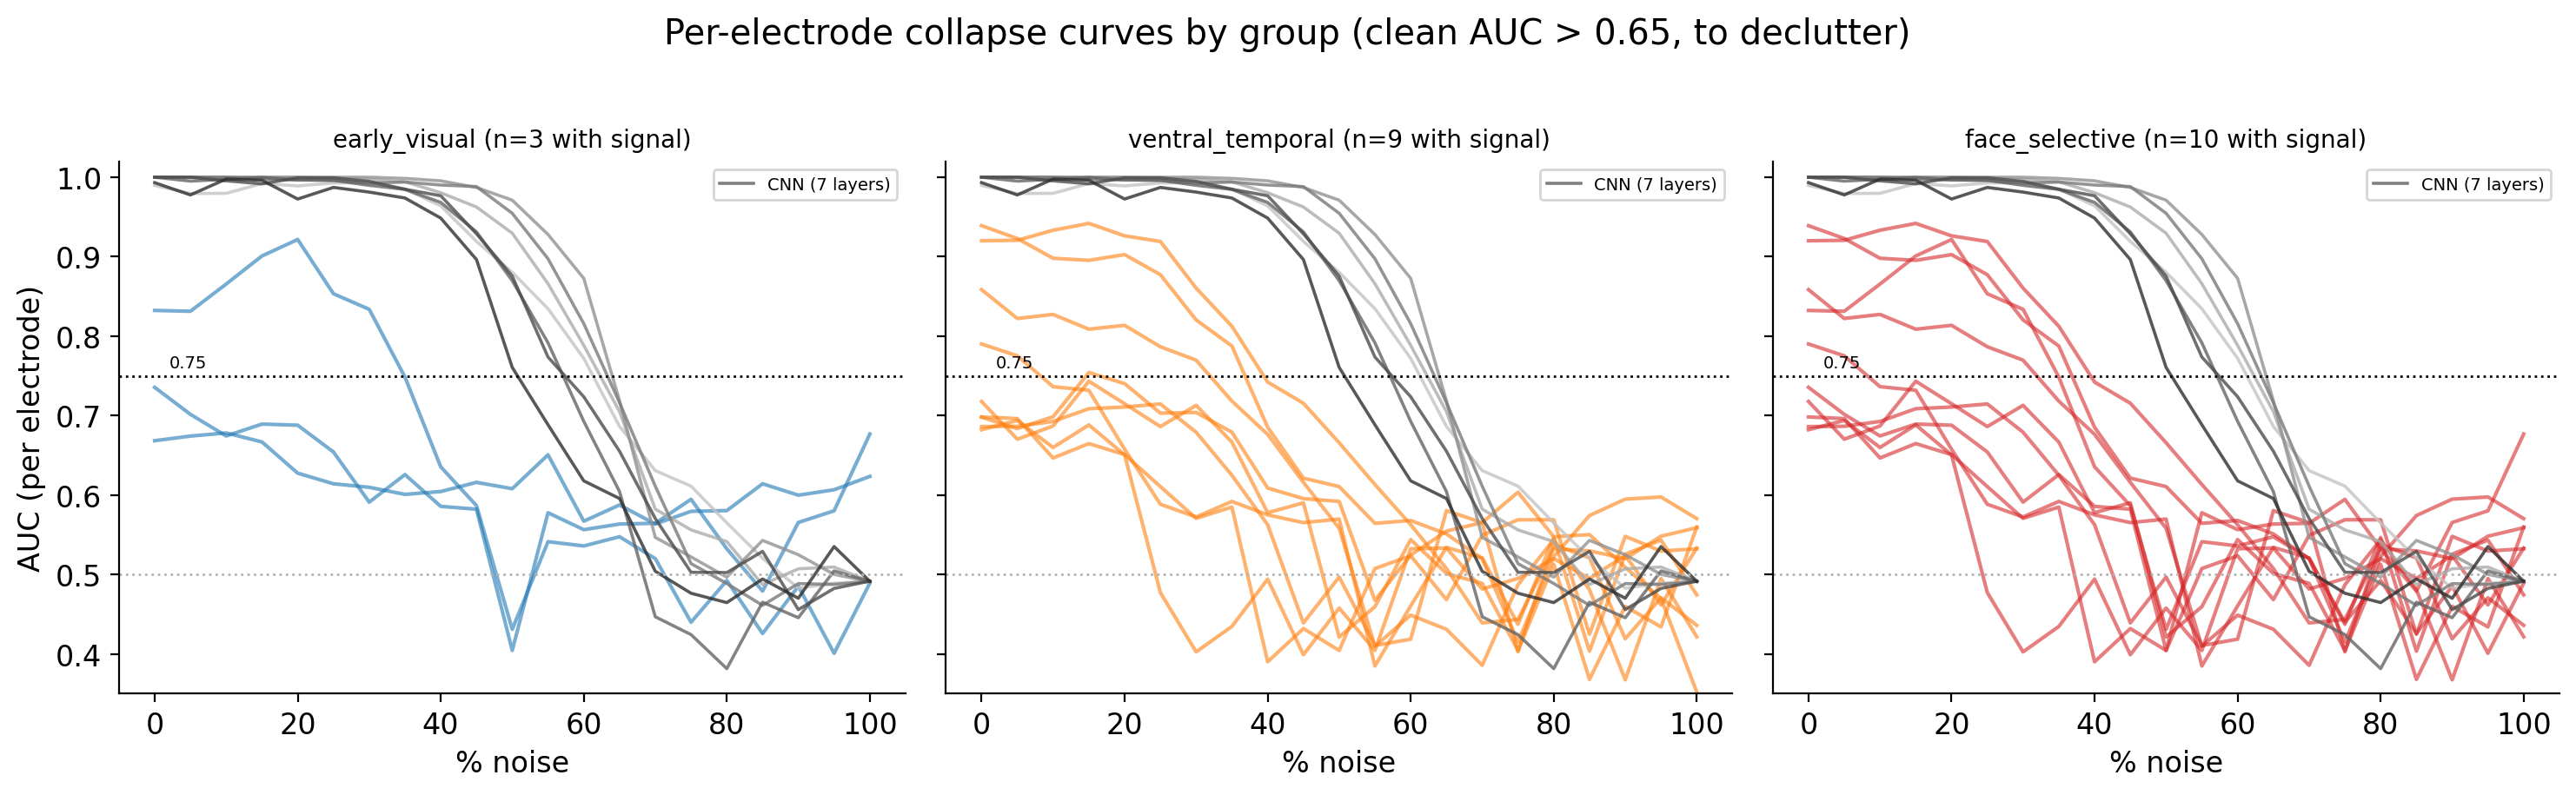

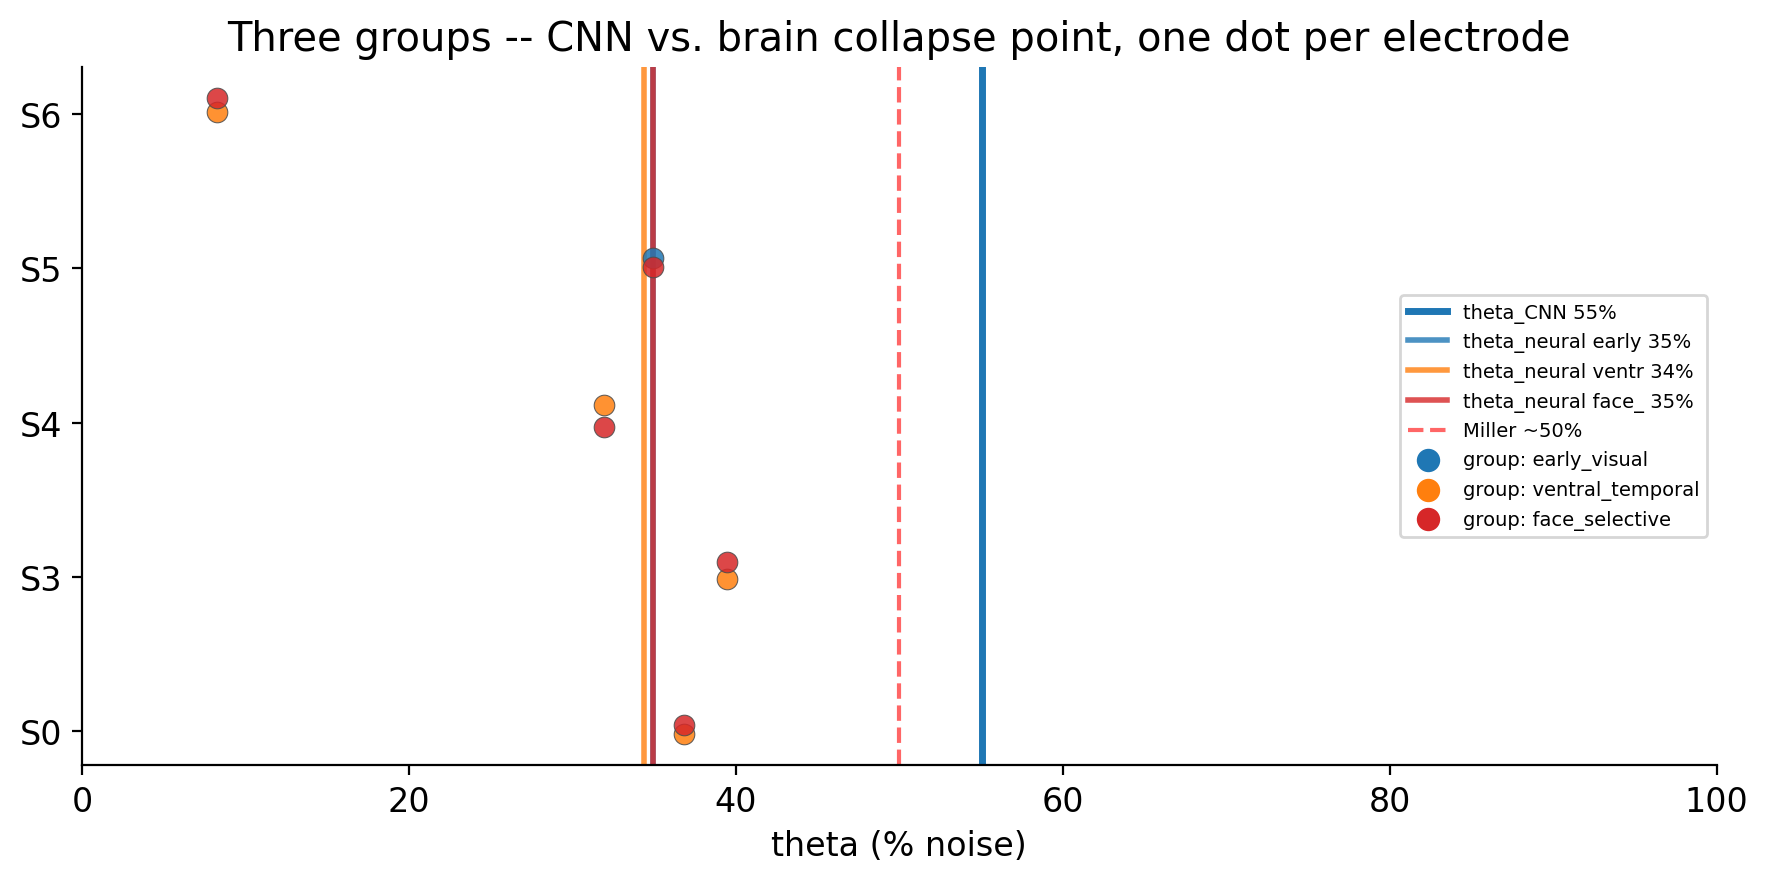

In [8]:
# @title Three groups -- per-electrode collapse curves and per-subject summary figures

CLEAN_MIN = 0.65   # visualization-only filter: only plot electrodes with a real clean-noise signal

def clean_auc(cv):
    return np.nanmean(cv[:3]) if cv is not None and np.isfinite(cv[:3]).any() else np.nan

fig, axes = plt.subplots(1, len(GROUPS3), figsize=(5*len(GROUPS3), 4.5), sharey=True)
for ax, g in zip(axes, GROUPS3):
    keys = {(int(r['subject']), int(r['channel'])) for _, r in neu3[neu3['group'] == g].iterrows()}
    n_plotted = 0
    for k in keys:
        cv = curve_store3.get(k)
        if cv is None or clean_auc(cv) < CLEAN_MIN:
            continue
        ax.plot(NOISE_LEVELS, cv, '-', color=GCOL3[g], alpha=.6, lw=1.5)
        n_plotted += 1
    grays = plt.cm.Greys(np.linspace(0.35, 0.85, len(cnn_thr)))
    for (_, r), gc in zip(cnn_thr.iterrows(), grays):
        ax.plot(NOISE_LEVELS, r['curve'], '-', color=gc, lw=1.3, alpha=.8)
    ax.plot([], [], '-', color='0.5', lw=1.3, label='CNN (7 layers)')
    ax.axhline(AUC_CRIT, color='k', ls=':', lw=1); ax.text(2, AUC_CRIT + .01, f'{AUC_CRIT}', fontsize=7)
    ax.axhline(0.5, color='0.7', ls=':', lw=1)
    ax.set_title(f'{g} (n={n_plotted} with signal)', fontsize=10)
    ax.set_xlabel('% noise'); ax.set_ylim(0.35, 1.02); ax.legend(fontsize=7)
axes[0].set_ylabel('AUC (per electrode)')
plt.suptitle(f'Per-electrode collapse curves by group (clean AUC > {CLEAN_MIN}, to declutter)', y=1.02)
plt.tight_layout(); display(Image(save_fig(fig, '08_collapse_thresholds_fig03'))); plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 4.6))
for yi, s in enumerate(usable):
    for g in GROUPS3:
        sub = neu3[(neu3['group'] == g) & (neu3['subject'] == s)].dropna(subset=['theta_neural'])
        if len(sub) == 0:
            continue
        ax.scatter(sub['theta_neural'], np.full(len(sub), yi) + np.random.uniform(-.12, .12, len(sub)),
                   color=GCOL3[g], s=55, alpha=.85, edgecolors='0.3', linewidths=.4, zorder=3)
ax.axvline(deep_cnn, color='tab:blue', lw=2.5, label=f'theta_CNN {deep_cnn:.0f}%')
for g in GROUPS3:
    med = neu3[neu3['group'] == g]['theta_neural'].median()
    if np.isfinite(med):
        ax.axvline(med, color=GCOL3[g], lw=2, alpha=.8, label=f'theta_neural {g[:5]} {med:.0f}%')
ax.axvline(50, color='r', ls='--', alpha=.6, label='Miller ~50%')
for g in GROUPS3:
    ax.scatter([], [], color=GCOL3[g], s=55, label=f'group: {g}')
ax.set_yticks(range(len(usable))); ax.set_yticklabels([f'S{s}' for s in usable])
ax.set_xlabel('theta (% noise)'); ax.set_xlim(0, 100)
ax.legend(fontsize=7, loc='center right')
ax.set_title('Three groups -- CNN vs. brain collapse point, one dot per electrode')
plt.tight_layout(); display(Image(save_fig(fig, '08_collapse_thresholds_fig04'))); plt.close(fig)



## Population collapse threshold: CNN vs. ECoG, matched methodology

`theta_CNN` is a classifier trained on **all units** of a layer at once.
`theta_neural` above was a classifier trained on **one electrode** at a
time -- a much weaker readout, which is why so few electrodes reached the
0.75 criterion. This section matches the two: a logistic-regression readout
over **all electrodes in a group simultaneously**, for both `dat2` regions
and the dat1-defined `face_selective` set, using the same criterion-crossing
definition of theta as the CNN side.


In [9]:
# @title Population collapse threshold: logistic readout over all electrodes in a group at once

POP_HALFWIN = 10
MIN_TRIALS_POP = 20
GROUPS_POP = ['early_visual', 'ventral_temporal', 'face_selective']
GCOL_POP = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange', 'face_selective': 'tab:red'}

def pop_curve(X, y, noise_v, halfwin=POP_HALFWIN, min_trials=MIN_TRIALS_POP):
    """Cross-validated AUC of a logistic readout over ALL columns (electrodes) of X.
    C=0.1: many electrodes, few trials per noise band -> regularize to avoid overfitting."""
    out = np.full(len(NOISE_LEVELS), np.nan)
    for k, n in enumerate(NOISE_LEVELS):
        m = np.abs(noise_v - n) <= halfwin
        if m.sum() < min_trials:
            continue
        yy = y[m]
        if len(np.unique(yy)) < 2 or np.bincount(yy).min() < 8:
            continue
        cv = StratifiedKFold(n_splits=min(5, np.bincount(yy).min()), shuffle=True, random_state=0)
        pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=0.1))
        out[k] = cross_val_score(pipe, X[m], yy, cv=cv, scoring='roc_auc').mean()
    return out

pop_rows, pop_curves = [], {}
for s in usable:
    c = elec_cache[s]
    resp, good = c['resp'], c['good']
    y_, nz_ = (c['cat'] == 2).astype(int), c['noise']
    sub_anat = electrode_type_df[electrode_type_df['subject'] == s]
    for g in GROUPS_POP:
        if g == 'face_selective':
            chans = {int(ch) for ch in good if face_sel_dat1.get((s, int(ch)), False)}
        else:
            chans = set(sub_anat.loc[sub_anat['region'] == g, 'channel'].astype(int))
        cols = [i for i, ch in enumerate(good) if ch in chans]
        if len(cols) < 2:
            print(f"  S{s} {g}: {len(cols)} electrode(s) -- skipped (need >=2)")
            continue
        curve = pop_curve(resp[:, cols], y_, nz_)
        pop_curves[(s, g)] = curve
        pop_rows.append(dict(subject=s, group=g, n_elec=len(cols),
                              theta_pop=threshold_cross(NOISE_LEVELS, curve),
                              auc_clean=np.nanmax(curve[:3]) if np.isfinite(curve[:3]).any() else np.nan))
pop_df = pd.DataFrame(pop_rows)

print(f"\nECoG population readout (criterion {AUC_CRIT}), all electrodes of a group voting together:")
for g in GROUPS_POP:
    sub = pop_df[pop_df['group'] == g]
    if not len(sub):
        continue
    print(f"\n  {g}:")
    for _, r in sub.iterrows():
        th = 'n/a' if not np.isfinite(r['theta_pop']) else f"{r['theta_pop']:.1f}%"
        print(f"    S{int(r['subject'])}: n_elec={int(r['n_elec']):>2}  AUC_clean={r['auc_clean']:.3f}  theta={th}")
    med = sub['theta_pop'].median()
    print(f"    MEDIAN theta = {med:.1f}%" if np.isfinite(med) else "    MEDIAN theta = n/a")

print(f"\n>>> MATCHED COMPARISON (both sides use a multi-unit / multi-electrode classifier, criterion {AUC_CRIT}):")
print(f"    theta_CNN (deep layers)        = {deep_cnn:.1f}%")
for g in GROUPS_POP:
    m = pop_df[pop_df['group'] == g]['theta_pop'].median()
    print(f"    theta_ECoG {g:<18} = " + (f"{m:.1f}%" if np.isfinite(m) else "n/a"))

print(f"\n{'crit':>5} | {'CNN deep':>9} | " + " | ".join(f"{g[:12]:>12}" for g in GROUPS_POP))
print('-' * (20 + 15*len(GROUPS_POP)))
for crit in [0.60, 0.65, 0.70, 0.75]:
    tc_vals = [threshold_cross(NOISE_LEVELS, r['curve'], crit) for _, r in cnn_thr.iterrows() if r['layer'] in ['pool5', 'fc6', 'fc7']]
    tc_vals = [t for t in tc_vals if np.isfinite(t)]
    tc = np.mean(tc_vals) if tc_vals else np.nan
    cells_ = []
    for g in GROUPS_POP:
        th = [threshold_cross(NOISE_LEVELS, pop_curves[(s, g)], crit) for s in usable if (s, g) in pop_curves]
        th = [t for t in th if np.isfinite(t)]
        cells_.append(f"{np.median(th):.1f}%" if th else "-")
    tc_str = f"{tc:.1f}%" if np.isfinite(tc) else "-"
    print(f"{crit:>5.2f} | {tc_str:>8} | " + " | ".join(f"{c:>12}" for c in cells_))


  S3 early_visual: 0 electrode(s) -- skipped (need >=2)



ECoG population readout (criterion 0.75), all electrodes of a group voting together:

  early_visual:
    S0: n_elec= 4  AUC_clean=0.598  theta=n/a
    S4: n_elec= 2  AUC_clean=0.600  theta=n/a
    S5: n_elec=16  AUC_clean=0.884  theta=32.6%
    S6: n_elec= 2  AUC_clean=0.610  theta=n/a
    MEDIAN theta = 32.6%

  ventral_temporal:
    S0: n_elec=19  AUC_clean=0.882  theta=36.4%
    S3: n_elec=19  AUC_clean=0.928  theta=40.1%
    S4: n_elec=13  AUC_clean=0.821  theta=31.1%
    S5: n_elec=11  AUC_clean=0.716  theta=n/a
    S6: n_elec=15  AUC_clean=0.770  theta=3.3%
    MEDIAN theta = 33.8%

  face_selective:
    S0: n_elec= 5  AUC_clean=0.911  theta=37.5%
    S3: n_elec= 5  AUC_clean=0.955  theta=41.2%
    S4: n_elec= 4  AUC_clean=0.869  theta=31.7%
    S5: n_elec= 7  AUC_clean=0.894  theta=33.0%
    S6: n_elec= 8  AUC_clean=0.828  theta=6.7%
    MEDIAN theta = 33.0%

>>> MATCHED COMPARISON (both sides use a multi-unit / multi-electrode classifier, criterion 0.75):
    theta_CNN (deep 

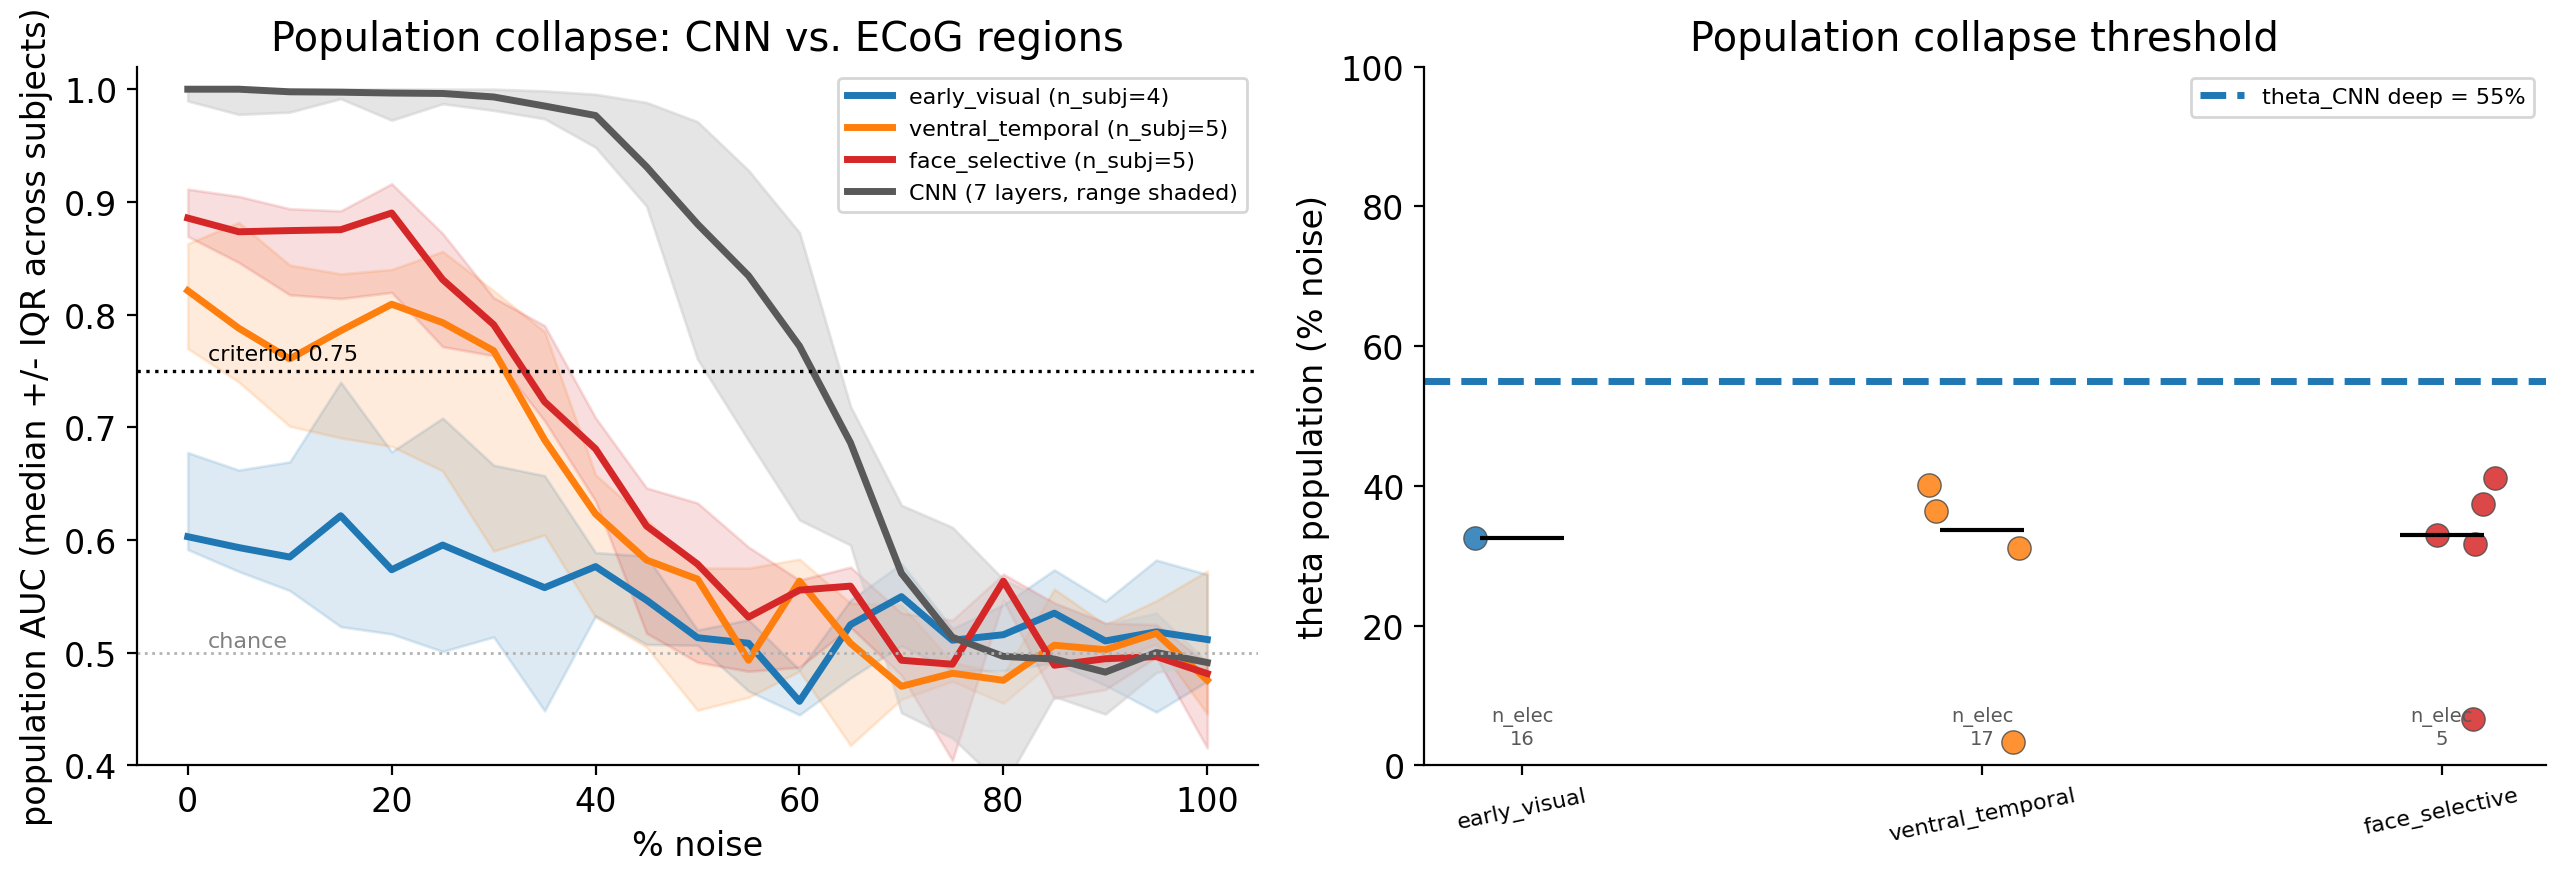

In [10]:
# @title Population collapse threshold: figures (collapse curves, threshold comparison)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for g in GROUPS_POP:
    cvs = [pop_curves[(s, g)] for s in usable if (s, g) in pop_curves]
    if not cvs:
        continue
    M = np.array(cvs)
    med = np.nanmedian(M, 0)
    ax[0].plot(NOISE_LEVELS, med, '-', color=GCOL_POP[g], lw=2.5, label=f'{g} (n_subj={len(cvs)})')
    if len(cvs) > 1:
        ax[0].fill_between(NOISE_LEVELS, np.nanpercentile(M, 25, 0), np.nanpercentile(M, 75, 0),
                           color=GCOL_POP[g], alpha=.15)
cnn_stack = np.array([r['curve'] for _, r in cnn_thr.iterrows()])
ax[0].fill_between(NOISE_LEVELS, np.nanmin(cnn_stack, 0), np.nanmax(cnn_stack, 0), color='0.8', alpha=.5)
ax[0].plot(NOISE_LEVELS, np.nanmedian(cnn_stack, 0), '-', color='0.35', lw=2.5, label='CNN (7 layers, range shaded)')
ax[0].axhline(AUC_CRIT, color='k', ls=':', lw=1.2); ax[0].axhline(0.5, color='0.7', ls=':', lw=1)
ax[0].text(2, AUC_CRIT + .01, f'criterion {AUC_CRIT}', fontsize=8); ax[0].text(2, .505, 'chance', fontsize=8, color='0.5')
ax[0].set_xlabel('% noise'); ax[0].set_ylabel('population AUC (median +/- IQR across subjects)')
ax[0].set_ylim(0.4, 1.02); ax[0].legend(fontsize=8)
ax[0].set_title('Population collapse: CNN vs. ECoG regions')

for i, g in enumerate(GROUPS_POP):
    sub = pop_df[pop_df['group'] == g].dropna(subset=['theta_pop'])
    if not len(sub):
        continue
    ax[1].scatter(np.full(len(sub), i) + np.random.uniform(-.12, .12, len(sub)), sub['theta_pop'],
                  color=GCOL_POP[g], s=70, alpha=.85, edgecolors='0.3', linewidths=.5, zorder=3)
    ax[1].scatter([i], [sub['theta_pop'].median()], marker='_', s=900, color='k', zorder=4)
    ax[1].annotate(f"n_elec\n{int(sub['n_elec'].median())}", (i, 3), ha='center', fontsize=7, color='0.35')
ax[1].axhline(deep_cnn, color='tab:blue', ls='--', lw=2.5, label=f'theta_CNN deep = {deep_cnn:.0f}%')
ax[1].set_xticks(range(len(GROUPS_POP))); ax[1].set_xticklabels(GROUPS_POP, rotation=12, fontsize=8)
ax[1].set_ylabel('theta population (% noise)'); ax[1].set_ylim(0, 100)
ax[1].legend(fontsize=8); ax[1].set_title('Population collapse threshold')
plt.tight_layout(); display(Image(save_fig(fig, '08_collapse_thresholds_fig05'))); plt.close(fig)



In [11]:
save_cache('08_collapse_thresholds', cnn_thr=cnn_thr, deep_cnn=deep_cnn, pop_df=pop_df, pop_curves=pop_curves)


Cached ['cnn_thr', 'deep_cnn', 'pop_df', 'pop_curves'] -> C:\Users\janak\GitHub\noisy-faces-brain-vs-cnn\cache\08_collapse_thresholds.pkl


'C:\\Users\\janak\\GitHub\\noisy-faces-brain-vs-cnn\\cache\\08_collapse_thresholds.pkl'